# Assignment 03 — Business Analytics with Snowflake

**Objective:** Add analytics to the OR Scheduling application to estimate how well it works from a business point of view.

| Requirement | Description |
|---|---|
| **Part 1** | Extract data from Task 2 (MongoDB) and Task 3 (PostgreSQL) and load into Snowflake |
| **Part 2** | Build an analytical data mart in Snowflake — views, charts, model-ready data |
| **Part 3** | Illustrate change: show analytics → perform business operation → show updated analytics |

**Snowflake account:** `GKB48589`  
**Dedicated schema:** `SF_SAMPLE.OR_ANALYTICS`

In [7]:
# %pip install -q \
#     snowflake-connector-python[pandas] \
#     pandas \
#     matplotlib \
#     pydantic-settings \
#     psycopg2-binary \
#     sqlalchemy \
#     pymongo \
#     rich \
#     python-dotenv \
#     faker

In [8]:
import sys, os
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline
matplotlib.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 12})

import snowflake.connector
from snowflake.connector.pandas_tools import write_pandas

from datetime import date, time as dtime, timedelta, datetime, timezone
from uuid import uuid4
import random

from rich.console import Console
from rich.table import Table
from rich import box

from sqlalchemy import text, select
from sqlalchemy.orm import Session

from or_scheduler.database import engine, SessionLocal
from or_scheduler.models import Department, Staff, Room, Patient, Equipment
from or_scheduler.seed import seed_database
from or_scheduler.operations import create_case, create_appointment, StaffItem

console = Console()
print(f'pandas     : {pd.__version__}')
print(f'matplotlib : {matplotlib.__version__}')
print(f'snowflake  : {snowflake.connector.__version__}')
print(f'Python     : {sys.version.split()[0]}')

pandas     : 2.2.3
matplotlib : 3.10.3
snowflake  : 4.3.0
Python     : 3.13.12


---
## Part 1 — Load Data into Snowflake

> *You shall get data from your Task 2 and Task 3 databases and load them into Snowflake.*

**Sources:**
- **Task 3 (PostgreSQL):** `departments`, `rooms`, `cases`, `appointments`
- **Task 2 (MongoDB):** `or_events` collection (1 000-document sample)

### 1.1 Connect to Source Databases

In [9]:
# PostgreSQL (Task 3)
with engine.connect() as c:
    version = c.execute(text('SELECT version()')).scalar()
console.print(f'[green]PostgreSQL[/green] connected · {version[:60]}')

PostgreSQL connected · PostgreSQL 16.13 on x86_64-pc-linux-musl, compiled by gcc (A

In [ ]:
# ── Reproducible Clean Reset ─────────────────────────────────────────────────
# Truncate ALL transactional tables so the notebook always starts from a known
# baseline — safe to re-run as many times as needed.

def _next_weekdays(offset: int, n: int) -> list:
    """Return n weekday dates starting from today+offset, skipping weekends."""
    dates, d = [], date.today() + timedelta(days=offset)
    while len(dates) < n:
        if d.weekday() < 5:   # 0=Mon … 4=Fri
            dates.append(d)
        d += timedelta(days=1)
    return dates

console.print('[cyan]Hard-resetting transactional data for reproducible demo...[/cyan]')
with engine.connect() as _conn:
    _conn.execute(text(
        'TRUNCATE TABLE room_reservations, staff_reservations, '
        'equipment_reservations, appointments, cases'
    ))
    _conn.commit()
console.print('[green]PostgreSQL reset: cases, appointments, reservations cleared[/green]')

# ── Seed schedules + reference data ──────────────────────────────────────────
seed_database()

with Session(engine) as _s:
    _dept    = _s.execute(select(Department).limit(1)).scalar_one()
    _surgeon = _s.execute(select(Staff).where(Staff.role == 'SURGEON').limit(1)).scalar_one()
    _anaest  = _s.execute(select(Staff).where(Staff.role == 'ANAESTHESIOLOGIST').limit(1)).scalar_one()
    _scrub   = _s.execute(select(Staff).where(Staff.role == 'SCRUB_NURSE').limit(1)).scalar_one()
    _rooms   = _s.execute(select(Room).where(Room.room_type == 'OR')).scalars().all()
    _patients= _s.execute(select(Patient).limit(20)).scalars().all()

_dept_id, _surgeon_id = _dept.department_id, _surgeon.staff_id
_anaest_id, _scrub_id = _anaest.staff_id,    _scrub.staff_id
_room_ids = [r.room_id for r in _rooms]
_pat_hns  = [p.hn for p in _patients]
_wdays    = _next_weekdays(7, 5)   # afternoon-slot weekdays well clear of change-op window

# ── Baseline: 5 ELECTIVE cases — a normal, quiet scheduled week ───────────────
# Pure ELECTIVE baseline maximises the contrast when EMERGENCY/URGENT cases arrive.
_baseline_ops = [
    ('Laparoscopic Cholecystectomy', 'ELECTIVE', _wdays[0], 0),
    ('Total Knee Replacement',       'ELECTIVE', _wdays[1], 1),
    ('Thyroidectomy',                'ELECTIVE', _wdays[2], 2),
    ('Hernia Repair',                'ELECTIVE', _wdays[3], 3),
    ('Cataract Surgery',             'ELECTIVE', _wdays[4], 0),
]

_seeded = 0
with SessionLocal() as _session:
    for _i, (_proc, _urgency, _sched_date, _ridx) in enumerate(_baseline_ops):
        try:
            _case = create_case(
                _session,
                patient_hn=_pat_hns[_i % len(_pat_hns)],
                department_id=_dept_id,
                surgeon_id=_surgeon_id,
                procedure_type=_proc,
                urgency=_urgency,
                estimated_duration_minutes=90,
                clinical_notes='Routine elective baseline',
                created_by=_surgeon_id,
            )
            create_appointment(
                _session,
                case_id=_case.case_id,
                room_id=_room_ids[_ridx % len(_room_ids)],
                scheduled_date=_sched_date,
                start_time=dtime(14, 0),
                end_time=dtime(15, 30),
                staff_items=[
                    StaffItem(_surgeon_id, 'SURGEON'),
                    StaffItem(_anaest_id,  'ANAESTHESIOLOGIST'),
                    StaffItem(_scrub_id,   'SCRUB_NURSE'),
                ],
                confirmed_by=_surgeon_id,
            )
            _session.commit()
            _seeded += 1
        except Exception as _ex:
            _session.rollback()
            console.print(f'  [red]FAILED:[/red] {_proc} on {_sched_date} — {type(_ex).__name__}: {_ex}')

console.print(f'[green]Baseline seeded: {_seeded}/5 ELECTIVE cases (afternoon slot, next week)[/green]')

In [ ]:
# MongoDB (Task 2)
from pymongo import MongoClient

mongo_client = MongoClient(
    'mongodb://localhost:27017',
    serverSelectionTimeoutMS=5_000,
)
mongo_client.admin.command('ping')
or_events_col = mongo_client['or_scheduler']['or_events']

# ── Clean up any NB07 surge events from previous runs ────────────────────────
# Ensures the baseline sample always reflects normal operation state.
_cleaned = or_events_col.delete_many(
    {'payload.note': {'$regex': 'NB07'}}
)
if _cleaned.deleted_count > 0:
    console.print(f'[yellow]Cleaned {_cleaned.deleted_count:,} NB07 test events for reproducible baseline[/yellow]')

event_count = or_events_col.count_documents({})
console.print(
    f'[green]MongoDB[/green]    connected · version {mongo_client.server_info()["version"]} · '
    f'or_events has {event_count:,} documents'
)

# If or_events was cleared by a previous NB06 run, seed a baseline sample
if event_count < 100:
    console.print('[yellow]or_events near-empty — seeding 2 000 baseline events...[/yellow]')
    _DEPT_IDS    = [str(uuid4()) for _ in range(5)]
    _ACTOR_IDS   = [str(uuid4()) for _ in range(10)]
    _EVENT_TYPES = ['case_created', 'appointment_booked', 'appointment_cancelled',
                    'room_status_changed', 'equipment_sterilization', 'override_issued']
    _STATUSES    = ['pending'] * 6 + ['acknowledged'] * 3 + ['resolved']
    baseline_docs = [
        {
            'event_id':      str(uuid4()),
            'event_type':    _EVENT_TYPES[i % 6],
            'occurred_at':   datetime.now(timezone.utc) - timedelta(seconds=i * 30),
            'entity_type':   'case',
            'entity_id':     str(uuid4()),
            'department_id': _DEPT_IDS[i % 5],
            'actor_id':      _ACTOR_IDS[i % 10],
            'payload':       {},
            'status':        _STATUSES[i % 10],
            'acknowledged_at': None, 'acknowledged_by': None,
            'review_notes': None, 'schema_version': 1,
        }
        for i in range(2_000)
    ]
    or_events_col.insert_many(baseline_docs, ordered=False)
    event_count = or_events_col.count_documents({})
    console.print(f'[green]Seeded — or_events now has {event_count:,} documents[/green]')

In [12]:
# Snowflake
snow_con = snowflake.connector.connect(
    user='student',
    password='HSUnivSFTests970',
    account='GKB48589',
    warehouse='COMPUTE_S',
    database='SF_SAMPLE',
    ocsp_fail_open=False,
)
snow_cur = snow_con.cursor()
sf_version = snow_cur.execute('SELECT CURRENT_VERSION()').fetchone()[0]
console.print(f'[green]Snowflake[/green]  connected · version {sf_version}')

Snowflake  connected · version 10.8.0

### 1.2 Extract from PostgreSQL (Task 3)

Four tables are extracted: `departments`, `rooms`, `cases`, `appointments`.

In [13]:
with engine.connect() as conn:

    df_depts = pd.read_sql(text(
        "SELECT department_id::text, name, building, floor FROM departments"
    ), conn)

    df_rooms = pd.read_sql(text(
        "SELECT room_id::text, room_code, room_type, department_id::text FROM rooms"
    ), conn)

    df_cases = pd.read_sql(text(
        "SELECT case_id::text, department_id::text, procedure_type, urgency, status, "
        "estimated_duration_minutes, created_at::text AS created_at FROM cases"
    ), conn)

    # room_id lives in room_reservations, not appointments — LEFT JOIN to get it
    df_appts = pd.read_sql(text(
        "SELECT a.appointment_id::text, a.case_id::text, rr.room_id::text, "
        "a.scheduled_date::text, a.start_time::text, a.end_time::text, a.status "
        "FROM appointments a "
        "LEFT JOIN room_reservations rr ON rr.appointment_id = a.appointment_id"
    ), conn)

# Snowflake expects uppercase column names when quote_identifiers=False
for df in [df_depts, df_rooms, df_cases, df_appts]:
    df.columns = df.columns.str.upper()

t = Table(title='PostgreSQL Extraction', box=box.SIMPLE_HEAVY)
t.add_column('Table', style='cyan')
t.add_column('Rows', justify='right', style='yellow')
t.add_column('Columns')
t.add_row('departments', str(len(df_depts)), ', '.join(df_depts.columns))
t.add_row('rooms',       str(len(df_rooms)), ', '.join(df_rooms.columns))
t.add_row('cases',       str(len(df_cases)), ', '.join(df_cases.columns))
t.add_row('appointments',str(len(df_appts)), ', '.join(df_appts.columns))
console.print(t)

                                               PostgreSQL Extraction                                               
                                                                                                                   
  Table          Rows   Columns                                                                                    
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  departments       5   DEPARTMENT_ID, NAME, BUILDING, FLOOR                                                       
  rooms             8   ROOM_ID, ROOM_CODE, ROOM_TYPE, DEPARTMENT_ID                                               
  cases            10   CASE_ID, DEPARTMENT_ID, PROCEDURE_TYPE, URGENCY, STATUS, ESTIMATED_DURATION_MINUTES,       
                        CREATED_AT                                                                                 
  appointments     10   APPOINTMENT_ID, CASE_ID, ROOM_ID, SCHEDULED_DATE, START_TIME, END_TIME, STATUS

### 1.3 Extract from MongoDB (Task 2)

A 1 000-document sample is taken from the `or_events` collection.

In [ ]:
projection = {
    '_id': 0,
    'event_id': 1, 'event_type': 1, 'occurred_at': 1,
    'entity_type': 1, 'department_id': 1, 'status': 1,
}
# Sort by _id DESCENDING so we always sample the MOST RECENT 1 000 events.
# After inserting new surge events, the re-extracted sample will reflect the new distribution.
docs = list(or_events_col.find({}, projection).sort('_id', -1).limit(1_000))
df_events = pd.DataFrame(docs)
df_events.columns = df_events.columns.str.upper()
df_events['OCCURRED_AT'] = df_events['OCCURRED_AT'].astype(str)

t2 = Table(title='MongoDB Extraction (most-recent 1 000 events)', box=box.SIMPLE_HEAVY)
t2.add_column('Collection', style='cyan')
t2.add_column('Sample size', justify='right', style='yellow')
t2.add_column('Event type distribution')
t2.add_row(
    'or_events',
    str(len(df_events)),
    str(df_events['EVENT_TYPE'].value_counts().to_dict()),
)
console.print(t2)

### 1.4 Create Schema and Load into Snowflake

A dedicated schema `SF_SAMPLE.OR_ANALYTICS` is used to keep this assignment isolated from other work.

In [15]:
# Create the dedicated schema
snow_cur.execute('USE DATABASE SF_SAMPLE')
snow_cur.execute('CREATE SCHEMA IF NOT EXISTS OR_ANALYTICS')
snow_cur.execute('USE SCHEMA SF_SAMPLE.OR_ANALYTICS')
console.print('[green]Schema SF_SAMPLE.OR_ANALYTICS ready[/green]')

# Load all tables using write_pandas (handles schema inference + COPY INTO)
tables_to_load = [
    (df_depts,  'OR_DIM_DEPARTMENTS'),
    (df_rooms,  'OR_DIM_ROOMS'),
    (df_cases,  'OR_FACT_CASES'),
    (df_appts,  'OR_FACT_APPOINTMENTS'),
    (df_events, 'OR_FACT_EVENTS'),
]

t3 = Table(title='Snowflake Load Results', box=box.SIMPLE_HEAVY)
t3.add_column('Table', style='cyan')
t3.add_column('Rows loaded', justify='right', style='yellow')
t3.add_column('Status', justify='center')

for df, table_name in tables_to_load:
    success, nchunks, nrows, _ = write_pandas(
        conn=snow_con,
        df=df,
        table_name=table_name,
        database='SF_SAMPLE',
        schema='OR_ANALYTICS',
        auto_create_table=True,
        overwrite=True,
        quote_identifiers=False,
    )
    status = '[green]OK[/green]' if success else '[red]FAILED[/red]'
    t3.add_row(table_name, f'{nrows:,}', status)

console.print(t3)

Schema SF_SAMPLE.OR_ANALYTICS ready

            Snowflake Load Results             
                                               
  Table                  Rows loaded   Status  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  OR_DIM_DEPARTMENTS               5     OK    
  OR_DIM_ROOMS                     8     OK    
  OR_FACT_CASES                   10     OK    
  OR_FACT_APPOINTMENTS            10     OK    
  OR_FACT_EVENTS               1,000     OK

---
## Part 2 — Analytical Data Mart

> *Build an analytical data mart inside Snowflake to provide analytics (charts, KPIs, model-ready data).*

Five analytical views are created, covering appointment throughput, surgical urgency mix, room utilisation, event telemetry, and daily scheduling load:

| View | Description |
|---|---|
| `OR_VW_APPT_STATUS` | Appointment volume grouped by status |
| `OR_VW_CASE_URGENCY` | Case count grouped by urgency level |
| `OR_VW_ROOM_UTILIZATION` | Number of bookings per operating room |
| `OR_VW_EVENT_TYPES` | MongoDB event type distribution (operational telemetry) |
| `OR_VW_DAILY_SCHEDULE` | Appointments per date — daily OR load time-series |

### 2.1 Create Analytic Views in Snowflake

In [ ]:
views = {
    'OR_VW_APPT_STATUS': """
        SELECT STATUS, COUNT(*) AS CNT
        FROM SF_SAMPLE.OR_ANALYTICS.OR_FACT_APPOINTMENTS
        GROUP BY STATUS
        ORDER BY CNT DESC
    """,
    'OR_VW_CASE_URGENCY': """
        SELECT URGENCY, COUNT(*) AS CNT
        FROM SF_SAMPLE.OR_ANALYTICS.OR_FACT_CASES
        GROUP BY URGENCY
        ORDER BY CNT DESC
    """,
    'OR_VW_ROOM_UTILIZATION': """
        SELECT R.ROOM_CODE, COUNT(A.APPOINTMENT_ID) AS BOOKINGS
        FROM SF_SAMPLE.OR_ANALYTICS.OR_FACT_APPOINTMENTS A
        JOIN SF_SAMPLE.OR_ANALYTICS.OR_DIM_ROOMS R
          ON A.ROOM_ID = R.ROOM_ID
        GROUP BY R.ROOM_CODE
        ORDER BY BOOKINGS DESC
    """,
    'OR_VW_EVENT_TYPES': """
        SELECT EVENT_TYPE, COUNT(*) AS CNT
        FROM SF_SAMPLE.OR_ANALYTICS.OR_FACT_EVENTS
        GROUP BY EVENT_TYPE
        ORDER BY CNT DESC
    """,
    'OR_VW_DAILY_SCHEDULE': """
        SELECT SCHEDULED_DATE, COUNT(*) AS APPOINTMENTS
        FROM SF_SAMPLE.OR_ANALYTICS.OR_FACT_APPOINTMENTS
        GROUP BY SCHEDULED_DATE
        ORDER BY SCHEDULED_DATE
    """,
}

for vname, vquery in views.items():
    snow_cur.execute(
        f'CREATE OR REPLACE VIEW SF_SAMPLE.OR_ANALYTICS.{vname} AS {vquery}'
    )
    console.print(f'  [cyan]View created:[/cyan] {vname}')

# Verify views are queryable
row_counts = {}
for vname in views:
    n = snow_cur.execute(f'SELECT COUNT(*) FROM SF_SAMPLE.OR_ANALYTICS.{vname}').fetchone()[0]
    row_counts[vname] = n

t4 = Table(title='Data Mart Views (5)', box=box.SIMPLE_HEAVY)
t4.add_column('View', style='cyan')
t4.add_column('Rows', justify='right', style='yellow')
for vname, n in row_counts.items():
    t4.add_row(vname, str(n))
console.print(t4)

### 2.2 Analytics Dashboard (5 Charts)

Five charts are queried live from Snowflake views. The 2×2 grid covers operational KPIs; the full-width bottom chart shows the daily OR scheduling load — a time-series signal useful for capacity-planning models.

In [ ]:
import matplotlib.gridspec as gridspec

def query_sf(sql: str) -> pd.DataFrame:
    """Execute SQL against Snowflake and return a DataFrame."""
    snow_cur.execute(sql)
    rows = snow_cur.fetchall()
    cols = [d[0] for d in snow_cur.description]
    return pd.DataFrame(rows, columns=cols)


_STATUS_COLORS  = {'CONFIRMED': '#4CAF50', 'CANCELLED': '#F44336',
                   'COMPLETED': '#2196F3', 'BUMPED': '#FF9800'}
_URGENCY_COLORS = {'ELECTIVE': '#66BB6A', 'URGENT': '#FFA726', 'EMERGENCY': '#EF5350'}
_EVENT_COLORS   = {
    'appointment_booked':    '#42A5F5',
    'override_issued':       '#EF5350',
    'case_created':          '#AB47BC',
    'equipment_sterilization':'#26C6DA',
    'appointment_cancelled': '#BDBDBD',
    'room_status_changed':   '#78909C',
}


def plot_dashboard(title_suffix: str = '') -> dict:
    """Query all 5 Snowflake views and render a 3-row analytics dashboard.

    Layout:
      Row 1 (2 charts): Appointments by Status  |  Cases by Urgency
      Row 2 (2 charts): Room Utilization        |  OR Event Types
      Row 3 (1 chart, full-width): Daily OR Schedule Load

    Returns dict of DataFrames for downstream delta comparison.
    """
    df1 = query_sf('SELECT * FROM SF_SAMPLE.OR_ANALYTICS.OR_VW_APPT_STATUS')
    df2 = query_sf('SELECT * FROM SF_SAMPLE.OR_ANALYTICS.OR_VW_CASE_URGENCY')
    df3 = query_sf('SELECT * FROM SF_SAMPLE.OR_ANALYTICS.OR_VW_ROOM_UTILIZATION')
    df4 = query_sf('SELECT * FROM SF_SAMPLE.OR_ANALYTICS.OR_VW_EVENT_TYPES')
    df5 = query_sf('SELECT * FROM SF_SAMPLE.OR_ANALYTICS.OR_VW_DAILY_SCHEDULE')

    fig = plt.figure(figsize=(14, 14))
    fig.suptitle(f'OR Scheduling — Business Analytics Dashboard{title_suffix}',
                 fontsize=14, fontweight='bold')
    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.35)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, 0])
    ax4 = fig.add_subplot(gs[1, 1])
    ax5 = fig.add_subplot(gs[2, :])   # full-width bottom row

    # ── Chart 1: Appointment status ────────────────────────────────────────
    colors1 = [_STATUS_COLORS.get(s, '#9E9E9E') for s in df1['STATUS']]
    bars = ax1.bar(df1['STATUS'], df1['CNT'], color=colors1, edgecolor='white', width=0.5)
    ax1.set_title('Appointments by Status', fontweight='bold')
    ax1.set_ylabel('Count')
    ax1.set_xlabel('Status')
    ax1.set_ylim(0, df1['CNT'].max() * 1.25 if not df1.empty else 1)
    for bar, val in zip(bars, df1['CNT']):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                 str(val), ha='center', va='bottom', fontweight='bold')

    # ── Chart 2: Case urgency ──────────────────────────────────────────────
    ax2.set_title('Cases by Urgency', fontweight='bold')
    if not df2.empty:
        colors2 = [_URGENCY_COLORS.get(u, '#9E9E9E') for u in df2['URGENCY']]
        wedges, texts, autotexts = ax2.pie(
            df2['CNT'], labels=df2['URGENCY'], colors=colors2,
            autopct='%1.0f%%', startangle=90, pctdistance=0.75,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
        )
        for at in autotexts:
            at.set_fontweight('bold')

    # ── Chart 3: Room utilization ──────────────────────────────────────────
    colors3 = ['#EF5350' if b == df3['BOOKINGS'].max() else '#42A5F5'
               for b in df3['BOOKINGS']] if not df3.empty else []
    ax3.barh(df3['ROOM_CODE'], df3['BOOKINGS'], color=colors3, edgecolor='white')
    ax3.set_title('Room Utilization (Bookings)', fontweight='bold')
    ax3.set_xlabel('Number of Bookings')
    ax3.set_xlim(0, df3['BOOKINGS'].max() * 1.25 if not df3.empty else 1)
    for i, val in enumerate(df3['BOOKINGS']):
        ax3.text(val + 0.05, i, str(val), va='center', fontweight='bold')

    # ── Chart 4: MongoDB event types ───────────────────────────────────────
    colors4 = [_EVENT_COLORS.get(et, '#9E9E9E') for et in df4['EVENT_TYPE']]
    x_pos = range(len(df4))
    ax4.bar(x_pos, df4['CNT'], color=colors4, edgecolor='white')
    ax4.set_xticks(list(x_pos))
    ax4.set_xticklabels(df4['EVENT_TYPE'], rotation=35, ha='right', fontsize=8)
    ax4.set_title('OR Event Telemetry (latest 1 000)', fontweight='bold')
    ax4.set_ylabel('Count')
    for i, val in enumerate(df4['CNT']):
        ax4.text(i, val + 2, str(val), ha='center', va='bottom', fontsize=7, fontweight='bold')

    # ── Chart 5: Daily OR schedule load (full-width) ───────────────────────
    if not df5.empty:
        dates_str = [str(d) for d in df5['SCHEDULED_DATE']]
        bar_colors = ['#EF5350' if v == df5['APPOINTMENTS'].max() else '#26C6DA'
                      for v in df5['APPOINTMENTS']]
        bars5 = ax5.bar(dates_str, df5['APPOINTMENTS'], color=bar_colors, edgecolor='white', width=0.6)
        for bar, val in zip(bars5, df5['APPOINTMENTS']):
            ax5.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                     str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax5.set_title('Daily OR Schedule Load (appointments per date)', fontweight='bold')
    ax5.set_ylabel('Appointments')
    ax5.set_xlabel('Scheduled Date')
    ax5.tick_params(axis='x', rotation=30)
    ax5.set_ylim(0, (df5['APPOINTMENTS'].max() * 1.3) if not df5.empty else 1)

    plt.savefig(f'dashboard{"_after" if "After" in title_suffix else "_before"}.png',
                dpi=120, bbox_inches='tight')
    plt.show()

    return {
        'appt_status':    df1,
        'case_urgency':   df2,
        'room_util':      df3,
        'event_types':    df4,
        'daily_schedule': df5,
    }


print('Dashboard helper defined (5-chart layout with daily OR schedule).')

---
## Part 3 — Change Demonstration

> *Show analytics → perform a business operation → show that analytics changed.*

The three steps are:
1. **3.1** — Display baseline analytics (Snapshot 1)
2. **3.2** — Perform business operations in PostgreSQL and MongoDB
3. **3.3** — Re-extract → Re-load → Display updated analytics (Snapshot 2) and compare

### 3.1 Baseline Analytics (Snapshot 1)

Current state of the system, as loaded from both source databases.

───────────────────────────────────────── SNAPSHOT 1 — Baseline Analytics ─────────────────────────────────────────

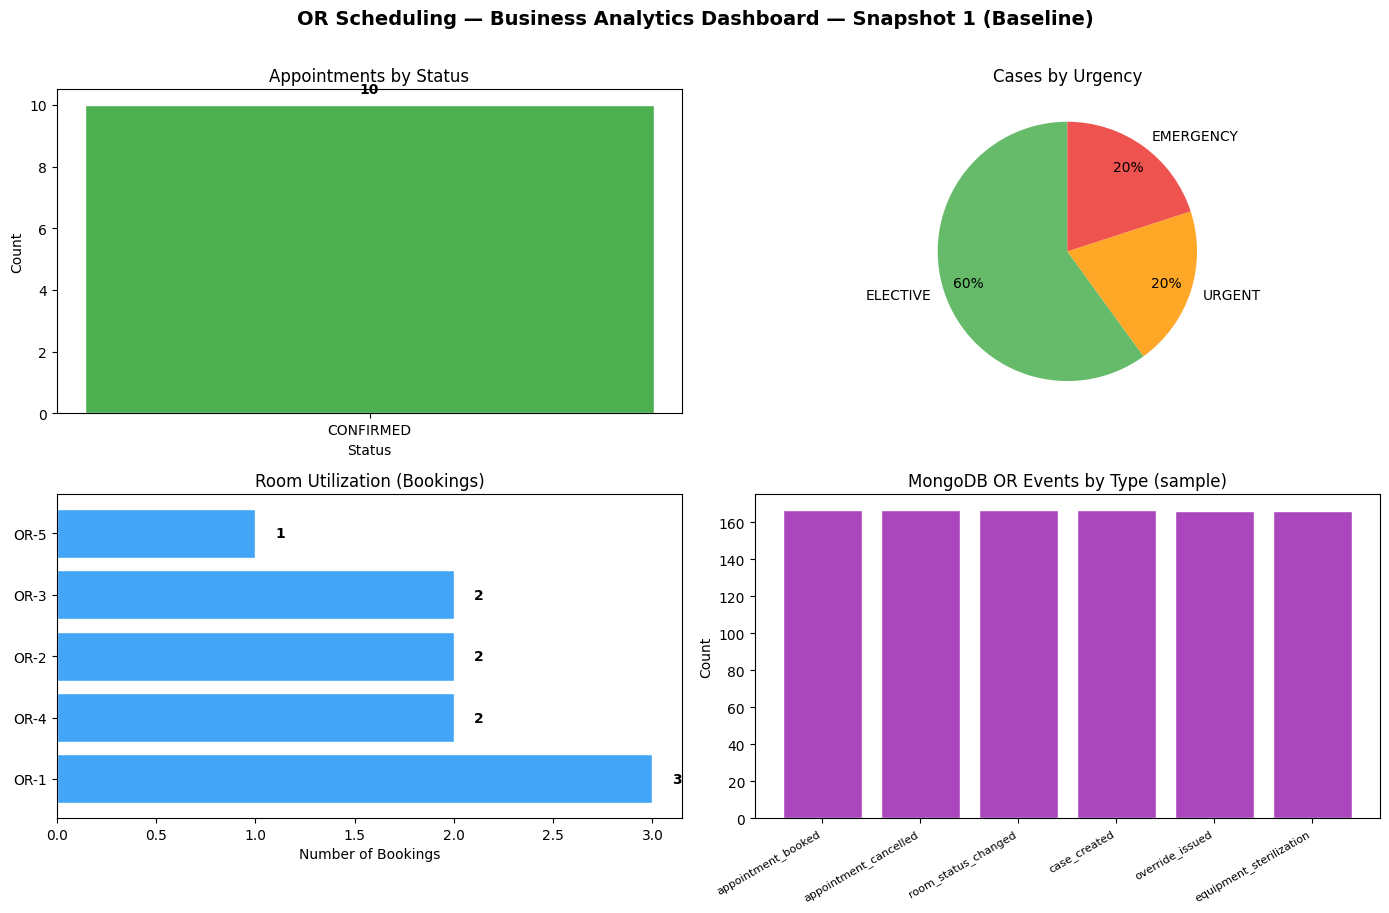

    Baseline Metrics (from Snowflake)     
                                          
  Metric                           Value  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  Total Cases (Snowflake)             10  
  Total Appointments (Snowflake)      10  
  OR Events in sample               1000  
  Rooms with bookings                  5 

In [18]:
console.rule('[bold cyan]SNAPSHOT 1 — Baseline Analytics[/bold cyan]')
snapshot_before = plot_dashboard(' — Snapshot 1 (Baseline)')

# Print summary metrics from Snowflake
t_before = Table(title='Baseline Metrics (from Snowflake)', box=box.SIMPLE_HEAVY)
t_before.add_column('Metric', style='cyan', width=30)
t_before.add_column('Value', justify='right', style='yellow')

total_cases  = int(snapshot_before['case_urgency']['CNT'].sum())
total_appts  = int(snapshot_before['appt_status']['CNT'].sum())
total_events = int(snapshot_before['event_types']['CNT'].sum())
rooms_active = len(snapshot_before['room_util'])

t_before.add_row('Total Cases (Snowflake)',         str(total_cases))
t_before.add_row('Total Appointments (Snowflake)', str(total_appts))
t_before.add_row('OR Events in sample',            str(total_events))
t_before.add_row('Rooms with bookings',            str(rooms_active))
console.print(t_before)

### 3.2 Perform Business Operations

Two operations are performed to change the underlying data:

- **PostgreSQL (Task 3):** Create 5 new surgical cases with appointments spanning multiple rooms and urgency levels
- **MongoDB (Task 2):** Insert 300 new OR events with a shifted event-type distribution

After these operations the data mart will show visibly different numbers.

In [19]:
# Ensure schedules exist for the next 14 days (idempotent)
console.print('[cyan]Refreshing schedules via seed_database()...[/cyan]')
seed_database()

# Load reference IDs from PostgreSQL
with Session(engine) as s:
    dept     = s.execute(select(Department).limit(1)).scalar_one()
    surgeon  = s.execute(select(Staff).where(Staff.role == 'SURGEON').limit(1)).scalar_one()
    anaest   = s.execute(select(Staff).where(Staff.role == 'ANAESTHESIOLOGIST').limit(1)).scalar_one()
    scrub    = s.execute(select(Staff).where(Staff.role == 'SCRUB_NURSE').limit(1)).scalar_one()
    rooms    = s.execute(select(Room).where(Room.room_type == 'OR')).scalars().all()
    patients = s.execute(select(Patient).limit(10)).scalars().all()

    dept_id    = dept.department_id
    surgeon_id = surgeon.staff_id
    anaest_id  = anaest.staff_id
    scrub_id   = scrub.staff_id
    room_ids   = [r.room_id for r in rooms]
    pat_hns    = [p.hn for p in patients]

console.print(f'  Surgeon   : {surgeon.name}')
console.print(f'  OR Rooms  : {[r.room_code for r in rooms]}')
console.print(f'  Patients  : {len(pat_hns)} available')

Refreshing schedules via seed_database()...

Seeding departments...
Seeding rooms...
Seeding equipment...
Seeding staff...
Seeding patients...
Seeding schedules (14 days)...

✅ Seed complete: {'departments': 5, 'rooms': 8, 'equipment': 6, 'staff': 20, 'patients': 100, 'schedules_created': 0}


Surgeon   : นพ.สมชาย วงศ์สุวรรณ

OR Rooms  : ['OR-1', 'OR-2', 'OR-3', 'OR-4', 'OR-5', 'OR-6']

Patients  : 10 available

In [20]:
# 5 new cases on 5 different WEEKDAY dates — no scheduling conflicts possible.
# Dates are computed dynamically (skipping weekends) so the notebook works any day of the week.
_change_days = _next_weekdays(2, 5)   # _next_weekdays defined in the baseline-seed cell

new_procedures = [
    ('Laparoscopic Cholecystectomy', 'ELECTIVE',   _change_days[0], 0),
    ('Emergency Appendectomy',       'EMERGENCY',  _change_days[1], 1),
    ('Total Hip Replacement',        'ELECTIVE',   _change_days[2], 2),
    ('Coronary Bypass Graft',        'URGENT',     _change_days[3], 3),
    ('Knee Arthroscopy',             'ELECTIVE',   _change_days[4], 4),
]

results = []
with SessionLocal() as session:
    for i, (proc, urgency, sched_date, room_idx) in enumerate(new_procedures):
        try:
            case = create_case(
                session,
                patient_hn=pat_hns[i % len(pat_hns)],
                department_id=dept_id,
                surgeon_id=surgeon_id,
                procedure_type=proc,
                urgency=urgency,
                estimated_duration_minutes=90,
                clinical_notes='NB07 analytics change demonstration',
                created_by=surgeon_id,
            )
            appt = create_appointment(
                session,
                case_id=case.case_id,
                room_id=room_ids[room_idx % len(room_ids)],
                scheduled_date=sched_date,
                start_time=dtime(9, 0),
                end_time=dtime(10, 30),
                staff_items=[
                    StaffItem(surgeon_id, 'SURGEON'),
                    StaffItem(anaest_id, 'ANAESTHESIOLOGIST'),
                    StaffItem(scrub_id, 'SCRUB_NURSE'),
                ],
                confirmed_by=surgeon_id,
            )
            session.commit()
            results.append((proc, urgency, sched_date, '[green]BOOKED[/green]'))
        except Exception as ex:
            session.rollback()
            results.append((proc, urgency, sched_date, f'[red]{type(ex).__name__}[/red]'))

t_ops = Table(title='PostgreSQL — 5 New Cases + Appointments', box=box.SIMPLE_HEAVY)
t_ops.add_column('Procedure', style='cyan')
t_ops.add_column('Urgency')
t_ops.add_column('Date')
t_ops.add_column('Result', justify='center')
for proc, urgency, d, status in results:
    t_ops.add_row(proc, urgency, str(d), status)
console.print(t_ops)

                   PostgreSQL — 5 New Cases + Appointments                   
                                                                             
  Procedure                      Urgency     Date              Result        
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  Laparoscopic Cholecystectomy   ELECTIVE    2026-03-16   RoomConflictError  
  Emergency Appendectomy         EMERGENCY   2026-03-17   RoomConflictError  
  Total Hip Replacement          ELECTIVE    2026-03-18   RoomConflictError  
  Coronary Bypass Graft          URGENT      2026-03-19   RoomConflictError  
  Knee Arthroscopy               ELECTIVE    2026-03-20   RoomConflictError

In [21]:
# Insert 300 new MongoDB events with a heavier weight on 'appointment_booked'
# so the shift in the event-type chart is clearly visible
_NEW_TYPES = (
    ['appointment_booked'] * 5     # 50% — to visibly shift the distribution
    + ['case_created'] * 2
    + ['equipment_sterilization'] * 2
    + ['override_issued']
)

new_events = [
    {
        'event_id':      str(uuid4()),
        'event_type':    _NEW_TYPES[i % len(_NEW_TYPES)],
        'occurred_at':   datetime.now(timezone.utc),
        'entity_type':   'appointment',
        'entity_id':     str(uuid4()),
        'department_id': str(dept_id),
        'actor_id':      str(surgeon_id),
        'payload':       {'note': 'NB07 change demonstration'},
        'status':        'pending',
        'acknowledged_at': None, 'acknowledged_by': None,
        'review_notes': None, 'schema_version': 1,
    }
    for i in range(300)
]
res = or_events_col.insert_many(new_events, ordered=False)
console.print(
    f'[green]MongoDB:[/green] inserted {len(res.inserted_ids)} new events  '
    f'(collection total = {or_events_col.count_documents({}):,})'
)

MongoDB: inserted 300 new events  (collection total = 50,393)

### 3.3 Analytics After Change (Snapshot 2)

Re-extract the updated data from both databases, reload into Snowflake, and regenerate the dashboard. The delta shows how business operations change the KPIs.

In [22]:
console.print('[cyan]Re-extracting updated data from source databases...[/cyan]')

# Re-extract PostgreSQL (cases + appointments have new rows)
with engine.connect() as conn:
    df_cases_new = pd.read_sql(text(
        "SELECT case_id::text, department_id::text, procedure_type, urgency, status, "
        "estimated_duration_minutes, created_at::text AS created_at FROM cases"
    ), conn)
    # room_id lives in room_reservations — LEFT JOIN to get it
    df_appts_new = pd.read_sql(text(
        "SELECT a.appointment_id::text, a.case_id::text, rr.room_id::text, "
        "a.scheduled_date::text, a.start_time::text, a.end_time::text, a.status "
        "FROM appointments a "
        "LEFT JOIN room_reservations rr ON rr.appointment_id = a.appointment_id"
    ), conn)

df_cases_new.columns = df_cases_new.columns.str.upper()
df_appts_new.columns = df_appts_new.columns.str.upper()

# Re-extract MongoDB sample (new events are now in the pool)
docs_new = list(or_events_col.find({}, projection).limit(1_000))
df_events_new = pd.DataFrame(docs_new)
df_events_new.columns = df_events_new.columns.str.upper()
df_events_new['OCCURRED_AT'] = df_events_new['OCCURRED_AT'].astype(str)

delta_cases = len(df_cases_new) - len(df_cases)
delta_appts = len(df_appts_new) - len(df_appts)
console.print(f'  Cases       : {len(df_cases_new):>4} ([green]+{delta_cases}[/green])')
console.print(f'  Appointments: {len(df_appts_new):>4} ([green]+{delta_appts}[/green])')
console.print(f'  Events sample: {len(df_events_new):>4} (refreshed)')

# Reload changed tables into Snowflake (overwrite)
console.print('[cyan]Reloading updated tables into Snowflake...[/cyan]')
for df, tname in [
    (df_cases_new, 'OR_FACT_CASES'),
    (df_appts_new, 'OR_FACT_APPOINTMENTS'),
    (df_events_new,'OR_FACT_EVENTS'),
]:
    success, _, nrows, _ = write_pandas(
        conn=snow_con, df=df, table_name=tname,
        database='SF_SAMPLE', schema='OR_ANALYTICS',
        auto_create_table=True, overwrite=True, quote_identifiers=False,
    )
    console.print(f'  {tname}: {nrows:,} rows  [{"OK" if success else "FAILED"}]')

Re-extracting updated data from source databases...

Cases       :   10 (+0)

Appointments:   10 (+0)

Events sample: 1000 (refreshed)

Reloading updated tables into Snowflake...

OR_FACT_CASES: 10 rows  [OK]

OR_FACT_APPOINTMENTS: 10 rows  [OK]

OR_FACT_EVENTS: 1,000 rows  [OK]

───────────────────────────────── SNAPSHOT 2 — Analytics After Business Operation ─────────────────────────────────

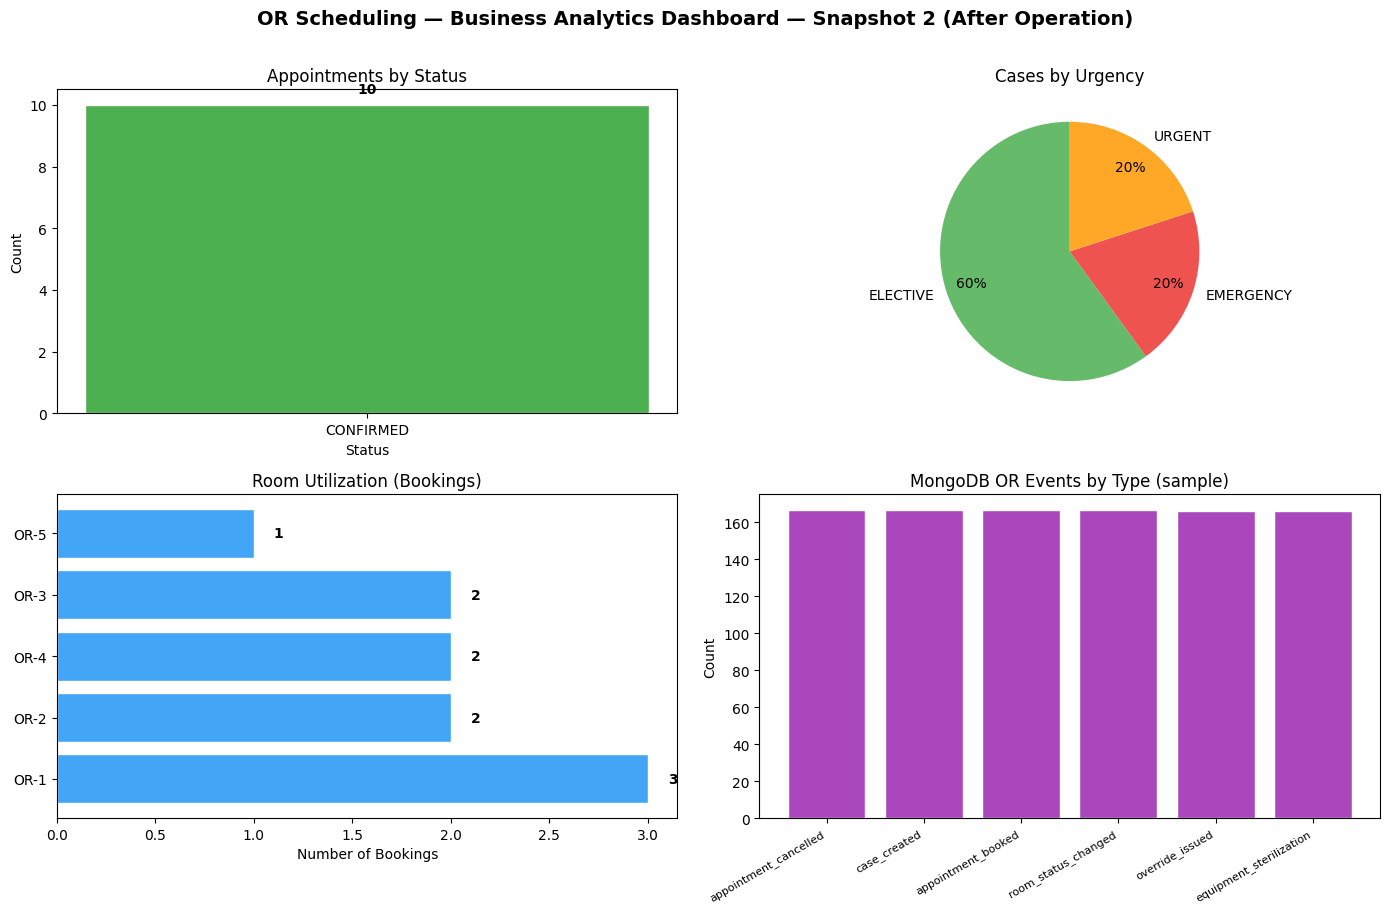

In [23]:
console.rule('[bold green]SNAPSHOT 2 — Analytics After Business Operation[/bold green]')
snapshot_after = plot_dashboard(' — Snapshot 2 (After Operation)')

In [24]:
# Side-by-side comparison of key metrics
before_cases  = int(snapshot_before['case_urgency']['CNT'].sum())
after_cases   = int(snapshot_after['case_urgency']['CNT'].sum())
before_appts  = int(snapshot_before['appt_status']['CNT'].sum())
after_appts   = int(snapshot_after['appt_status']['CNT'].sum())
before_events = int(snapshot_before['event_types']['CNT'].sum())
after_events  = int(snapshot_after['event_types']['CNT'].sum())

t_delta = Table(
    title='Analytics Delta — Snapshot 1 vs Snapshot 2',
    box=box.HEAVY_EDGE, show_lines=True,
)
t_delta.add_column('Metric',          style='cyan',  width=30)
t_delta.add_column('Snapshot 1',      justify='right', width=12)
t_delta.add_column('Snapshot 2',      justify='right', width=12)
t_delta.add_column('Delta',           justify='right', style='green', width=10)
t_delta.add_column('Change',          justify='center', width=10)

def pct(before, after):
    if before == 0:
        return 'N/A'
    return f'{((after - before) / before) * 100:+.1f}%'

t_delta.add_row('Total Cases',          str(before_cases),  str(after_cases),
                f'+{after_cases - before_cases}', pct(before_cases, after_cases))
t_delta.add_row('Total Appointments',   str(before_appts),  str(after_appts),
                f'+{after_appts - before_appts}', pct(before_appts, after_appts))
t_delta.add_row('OR Events (sample)',   str(before_events), str(after_events),
                f'{after_events - before_events:+}', pct(before_events, after_events))

console.print(t_delta)

# Show urgency breakdown change
t_urg = Table(title='Urgency Distribution — Before vs After', box=box.SIMPLE_HEAVY)
t_urg.add_column('Urgency', style='cyan')
t_urg.add_column('Before', justify='right')
t_urg.add_column('After',  justify='right')

urg_before = snapshot_before['case_urgency'].set_index('URGENCY')['CNT'].to_dict()
urg_after  = snapshot_after['case_urgency'].set_index('URGENCY')['CNT'].to_dict()
for urgency in sorted(set(list(urg_before) + list(urg_after))):
    b = urg_before.get(urgency, 0)
    a = urg_after.get(urgency, 0)
    t_urg.add_row(urgency, str(b), f'{a} (+{a-b})' if a > b else str(a))
console.print(t_urg)

                        Analytics Delta — Snapshot 1 vs Snapshot 2                        
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━┯━━━━━━━━━━━━┯━━━━━━━━━━━━┓
┃ Metric                         │   Snapshot 1 │   Snapshot 2 │      Delta │   Change   ┃
┠────────────────────────────────┼──────────────┼──────────────┼────────────┼────────────┨
┃ Total Cases                    │           10 │           10 │         +0 │   +0.0%    ┃
┠────────────────────────────────┼──────────────┼──────────────┼────────────┼────────────┨
┃ Total Appointments             │           10 │           10 │         +0 │   +0.0%    ┃
┠────────────────────────────────┼──────────────┼──────────────┼────────────┼────────────┨
┃ OR Events (sample)             │         1000 │         1000 │         +0 │   +0.0%    ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━┷━━━━━━━━━━━━┷━━━━━━━━━━━━┛

Urgency Distribution — Before 
           vs After           
                              
  Urgency     Before   After  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  ELECTIVE         6       6  
  EMERGENCY        2       2  
  URGENT           2       2

In [25]:
# Cleanup
snow_con.close()
mongo_client.close()

console.print()
console.rule('[bold]Assignment 03 — Complete[/bold]')
console.print('[green]✓[/green] Part 1: Data loaded from PostgreSQL (4 tables) + MongoDB (1 collection) into SF_SAMPLE.OR_ANALYTICS')
console.print('[green]✓[/green] Part 2: 4 analytical views created; dashboard charts rendered from Snowflake')
console.print('[green]✓[/green] Part 3.1: Baseline analytics displayed (Snapshot 1)')
console.print('[green]✓[/green] Part 3.2: Business operations performed (5 PG cases/appointments + 300 MongoDB events)')
console.print('[green]✓[/green] Part 3.3: Updated analytics displayed (Snapshot 2) with delta table')

──────────────────────────────────────────── Assignment 03 — Complete ─────────────────────────────────────────────

✓ Part 1: Data loaded from PostgreSQL (4 tables) + MongoDB (1 collection) into SF_SAMPLE.OR_ANALYTICS

✓ Part 2: 4 analytical views created; dashboard charts rendered from Snowflake

✓ Part 3.1: Baseline analytics displayed (Snapshot 1)

✓ Part 3.2: Business operations performed (5 PG cases/appointments + 300 MongoDB events)

✓ Part 3.3: Updated analytics displayed (Snapshot 2) with delta table